PHASE2: UNDERSTANDING FX DATA

In [10]:
import pandas as pd

df_fx_curr = pd.read_csv("../data/processed/fx_dataset_clean.csv")
df_fx_curr["Day"] = pd.to_datetime(df_fx_curr["Day"])

# ============================================================
# STEP 3.1 — Time Range & Basic Overview
# ============================================================

print("Start date:", df_fx_curr["Day"].min())
print("End date:", df_fx_curr["Day"].max())

print("\nNumber of observations:", len(df_fx_curr))
print("Number of trading dates:", df_fx_curr["Day"].nunique())

print("\nNumber of currencies:", len(df_fx_curr.columns) - 1)

print("\nCurrencies:")
print(df_fx_curr.columns[1:].tolist())

print("\nObservations per currency:")
print(df_fx_curr.iloc[:, 1:].count())

# ============================================================
# STEP 3.2 — Exchange-Rate Statistics
# ============================================================

print("Exchange-rate statistics:")
print(df_fx_curr.iloc[:, 1:].describe().T)

Start date: 2015-01-02 00:00:00
End date: 2026-09-15 00:00:00

Number of observations: 2996
Number of trading dates: 2996

Number of currencies: 9

Currencies:
['Value-CNY', 'Value-EUR', 'Value-INR', 'Value-ZAR', 'Value-TRY', 'Value-JPY', 'Value-GBP', 'Value-BRL', 'Value-AUD']

Observations per currency:
Value-CNY    2996
Value-EUR    2996
Value-INR    2996
Value-ZAR    2996
Value-TRY    2996
Value-JPY    2996
Value-GBP    2996
Value-BRL    2996
Value-AUD    2996
dtype: int64
Exchange-rate statistics:
            count        mean        std        min         25%         50%  \
Value-CNY  2996.0    6.798704   0.316512   6.193116    6.520876    6.829245   
Value-EUR  2996.0    0.892866   0.041496   0.800448    0.859679    0.891822   
Value-INR  2996.0   75.317115   8.840468  61.384221   67.326302   73.849160   
Value-ZAR  2996.0   15.576043   2.099115  11.311785   13.977222   15.251803   
Value-TRY  2996.0   15.437735  14.331818   2.281022    3.795951    7.447954   
Value-JPY  2996.0  

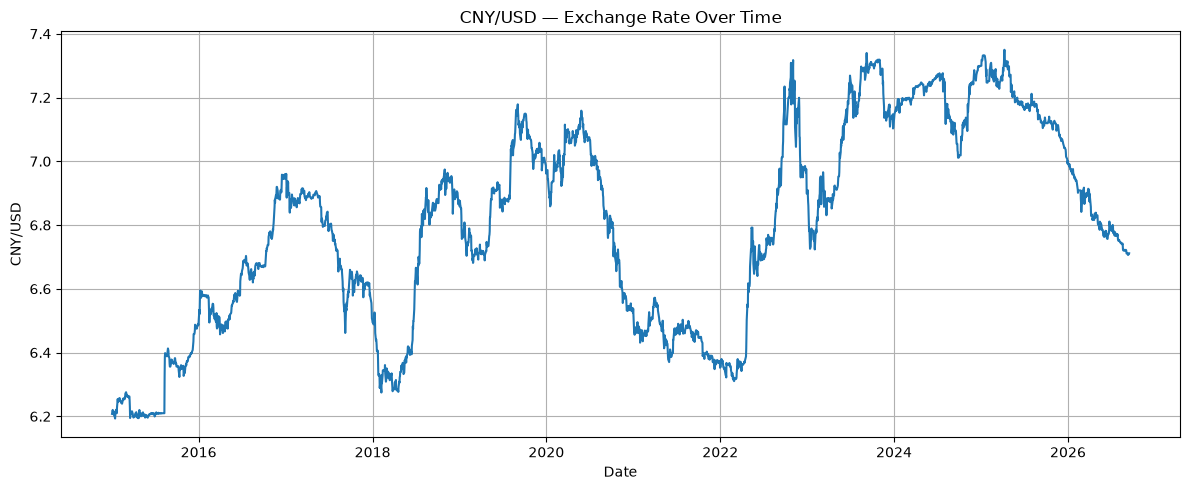

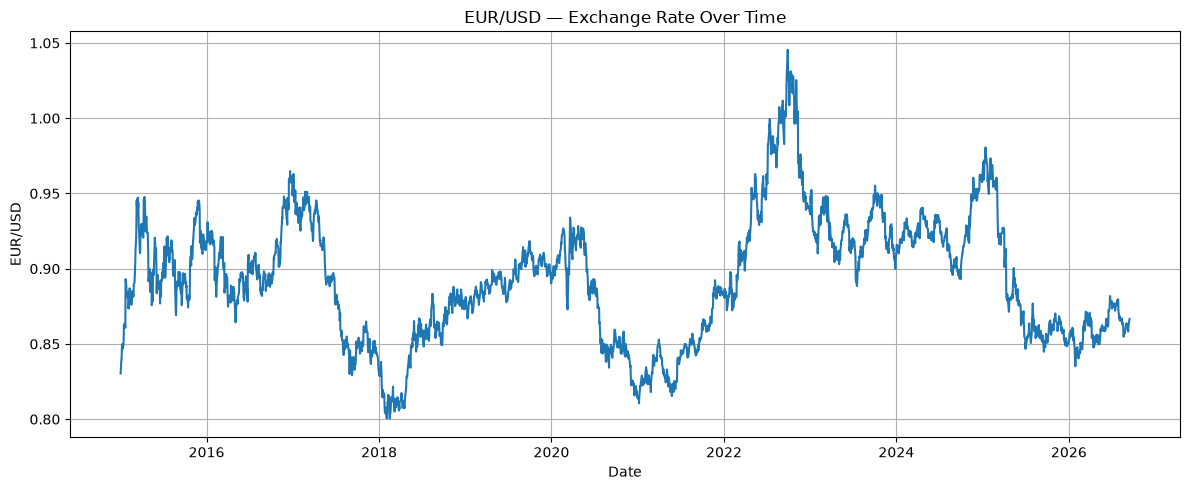

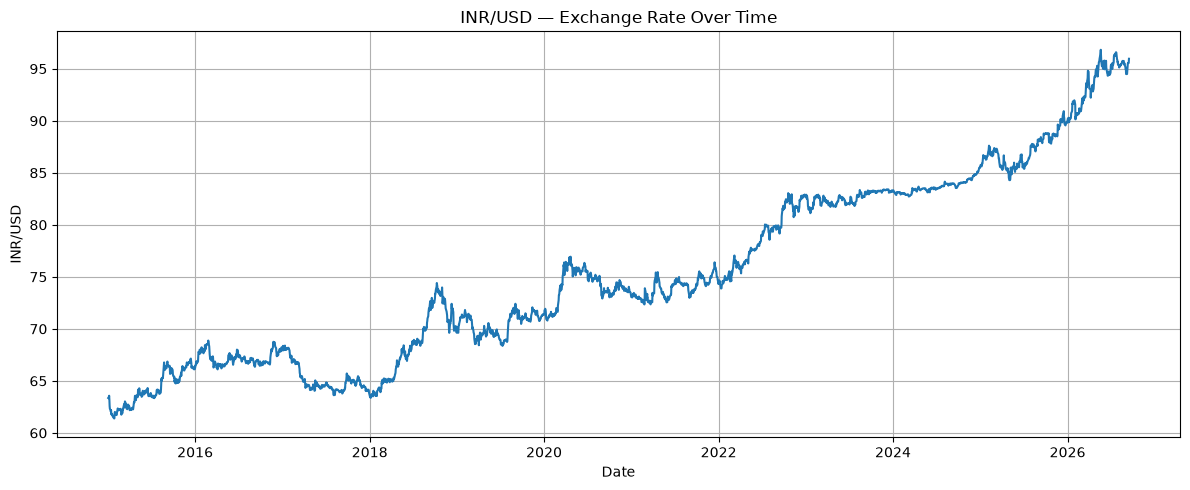

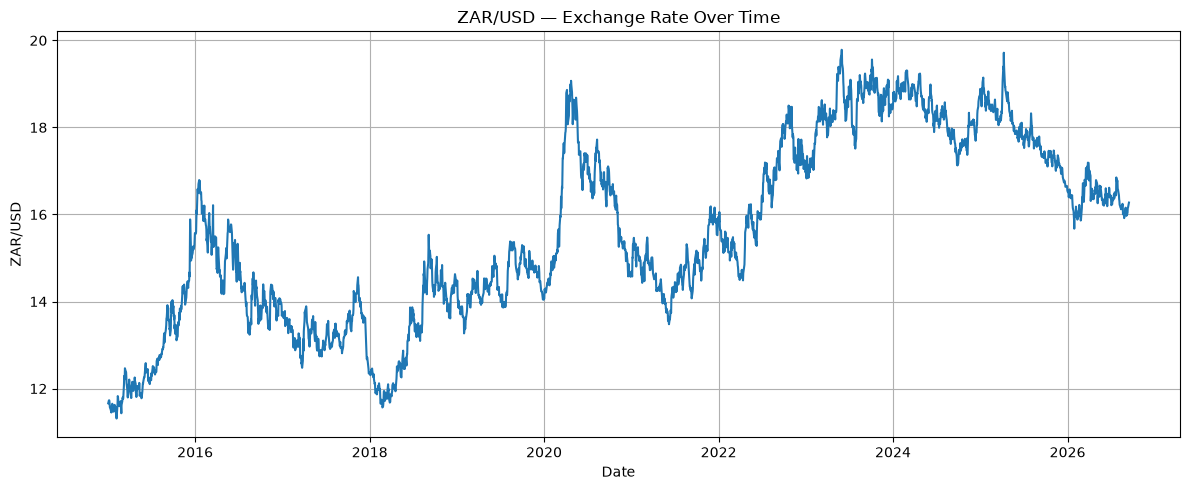

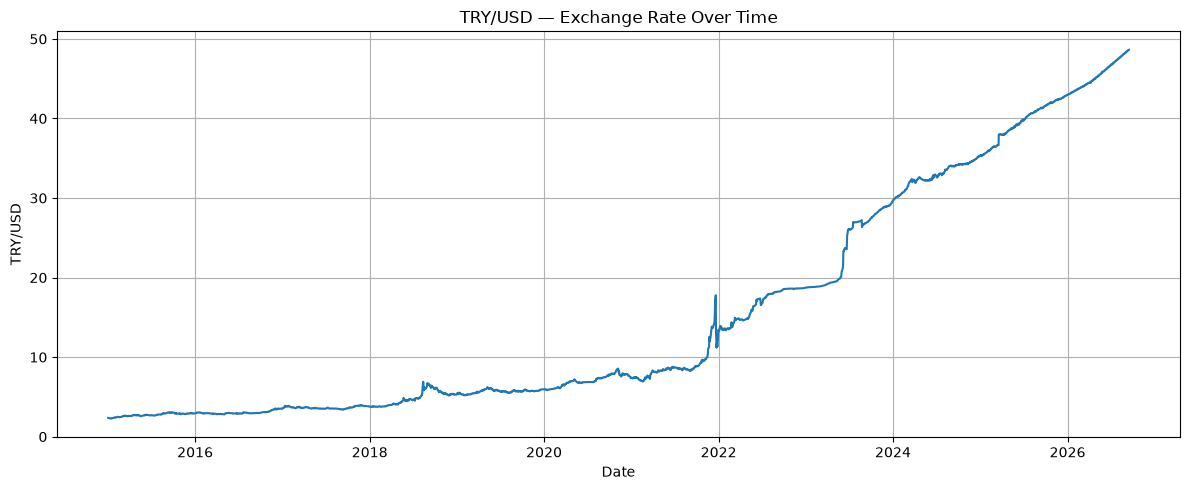

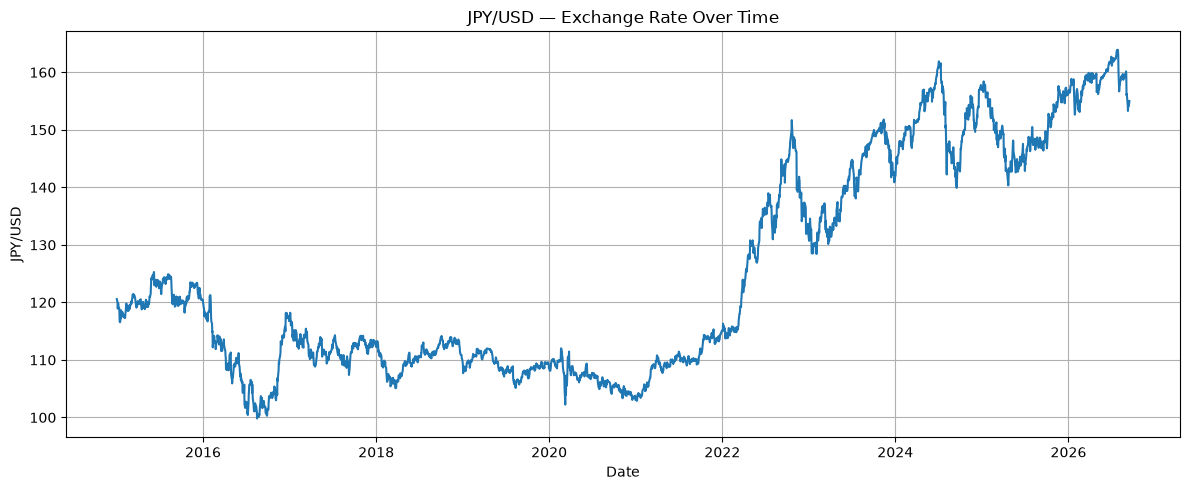

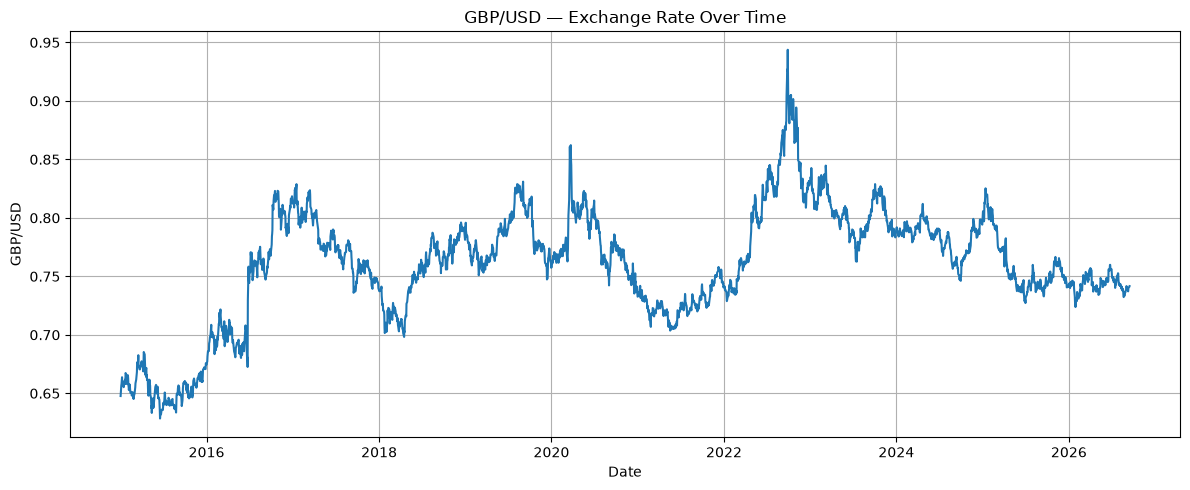

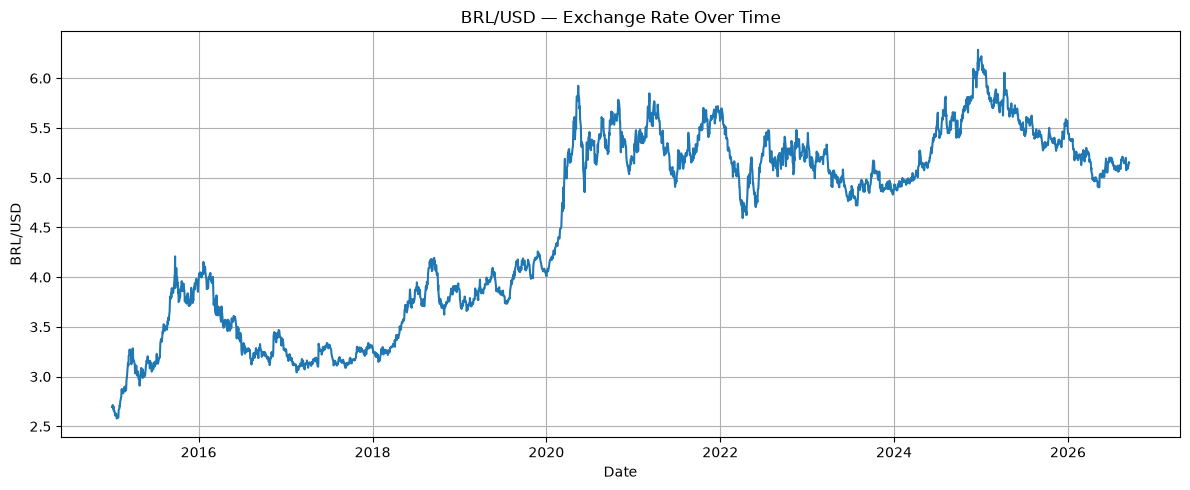

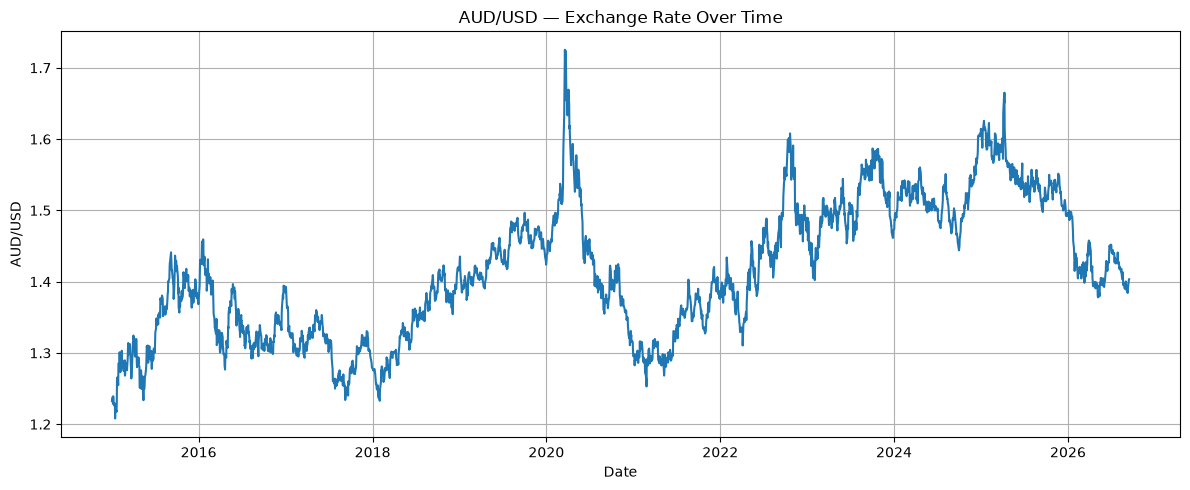

In [12]:
# ============================================================
# STEP 3.3 — Historical FX Plots
# ============================================================

import matplotlib.pyplot as plt

currency_pairs = {
    "Value-CNY": "CNY/USD",
    "Value-EUR": "EUR/USD",
    "Value-INR": "INR/USD",
    "Value-ZAR": "ZAR/USD",
    "Value-TRY": "TRY/USD",
    "Value-JPY": "JPY/USD",
    "Value-GBP": "GBP/USD",
    "Value-BRL": "BRL/USD",
    "Value-AUD": "AUD/USD"}

for currency in df_fx_curr.columns[1:]:
    pair = currency_pairs[currency]

    plt.figure(figsize=(12, 5))
    plt.plot(df_fx_curr["Day"], df_fx_curr[currency])

    plt.title(f"{pair} — Exchange Rate Over Time")
    plt.xlabel("Date")
    plt.ylabel(pair)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [15]:
# ============================================================
# STEP 3.4 — Exchange-Rate Distribution & Extreme Levels
# ============================================================

for currency in df_fx_curr.columns[1:]:
    
    series = df_fx_curr[currency]
    
    min_idx = series.idxmin()
    max_idx = series.idxmax()
    
    print(f"\n{currency}")
    print("-" * 50)
    
    print("Mean:           ", series.mean())
    print("Median:         ", series.median())
    print("25th percentile:", series.quantile(0.25))
    print("75th percentile:", series.quantile(0.75))
    
    print(
          "Minimum:        ",
        series.min(),
        "| Date:",
        df_fx_curr.loc[min_idx, "Day"]
    )
    
    print(
          "Maximum:        ",
        series.max(),
        "| Date:",
        df_fx_curr.loc[max_idx, "Day"]
    )


Value-CNY
--------------------------------------------------
Mean:            6.798704337783711
Median:          6.829245
25th percentile: 6.520876250000001
75th percentile: 7.07921825
Minimum:         6.193116 | Date: 2015-01-15 00:00:00
Maximum:         7.349842 | Date: 2025-04-09 00:00:00

Value-EUR
--------------------------------------------------
Mean:            0.8928662136181575
Median:          0.891822
25th percentile: 0.8596785
75th percentile: 0.920408
Minimum:         0.800448 | Date: 2018-02-15 00:00:00
Maximum:         1.045478 | Date: 2022-09-28 00:00:00

Value-INR
--------------------------------------------------
Mean:            75.31711489285713
Median:          73.8491605
25th percentile: 67.326302
75th percentile: 82.99695224999999
Minimum:         61.384221 | Date: 2015-01-27 00:00:00
Maximum:         96.825 | Date: 2026-05-20 00:00:00

Value-ZAR
--------------------------------------------------
Mean:            15.576043308411217
Median:          15.251802999